# IMPORTS

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler, FunctionTransformer
from sklearn.impute import SimpleImputer


# LOAD THE DATASET

In [170]:
url = "https://raw.githubusercontent.com/Bumb1eBee20/ExcelR---Data-Science-Assignments-Submissions/2ec0ad2e66b80821fd0918d6991c21bdf37230dc/9.%20Data%20Transformation/data/adult_with_headers%20(1).csv"
df = pd.read_csv(url)

# Preview of the Dataset

In [171]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


# Data Preprocessing

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Dimensions of Data

In [173]:
print("Shape : ",df.shape)
print("Size : ",df.size)

Shape :  (32561, 15)
Size :  488415


## Checking Missing Values and Duplicate Records

In [174]:
print("No.of Null Values : \n",df.isnull().sum())
print("="*100)
print("No.of Duplicate records : \n",df.duplicated().sum())

No.of Null Values : 
 age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64
No.of Duplicate records : 
 24


**Observation :**

The Dataset has no Missing values as of now. but it has 24 duplicate records which needed to be removed in order to maintain the quality of the data.

## Removing Duplicate Records

In [175]:
df.drop_duplicates(inplace = True)
print("No.of Duplicates after removal : ",df.duplicated().sum())

No.of Duplicates after removal :  0


## Removing White Spaces from Categorical Columns

In [176]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns
print("Numerical Columns : \n\n",numerical_cols)
print("="*100)
print("Categorical Columns : \n\n",categorical_cols)

Numerical Columns : 

 Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
Categorical Columns : 

 Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [177]:
for col in categorical_cols:
  df[col] = df[col].str.strip()
print("White Spaces Removed Successfully!!!")

White Spaces Removed Successfully!!!


## Statistical Information

In [178]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [179]:
mean = df.mean(numeric_only=True)
median = df.median(numeric_only=True)
mode = df.mode(numeric_only=True).iloc[0]
std = df.std(numeric_only=True)

stat_summary = pd.DataFrame({"Mean":mean,"Median":median,"Mode":mode,"Standard Deviation":std})
stat_summary

,Mean,Median,Mode,Standard Deviation
age,38.585549,37.0,36.0,13.637984
fnlwgt,189780.848511,178356.0,123011.0,105556.471009
education_num,10.081815,10.0,9.0,2.571633
capital_gain,1078.443741,0.0,0.0,7387.957424
capital_loss,87.368227,0.0,0.0,403.101833
hours_per_week,40.440329,40.0,40.0,12.346889


**Observation :**

- The Descriptive Statistics shows the dataset contains 32,537 non-null observations for the numerical variables.
- The fnlwgt has a large range and high variability, as its values ranges from 12,285 to 14,84,705.

- The education_num variable ranges from 1 to 16, with most observations falling between 9 and 12. This indicates that the dataset contains individuals with varying educational backgrounds.

- 50% of people are between 28 to 48 years old.

- A median of 10 indicates that atleast 50% of reords are contains high school or college peoples.

- over 75% of individuals reported $0 for both capital gains and losses.

- Both `Capital Gain` and `Capital Loss` variables are highly Right Skewed.

- Most of the people are working 40 hours per week.

# Visualizations

## BOXPLOT ANALYSIS

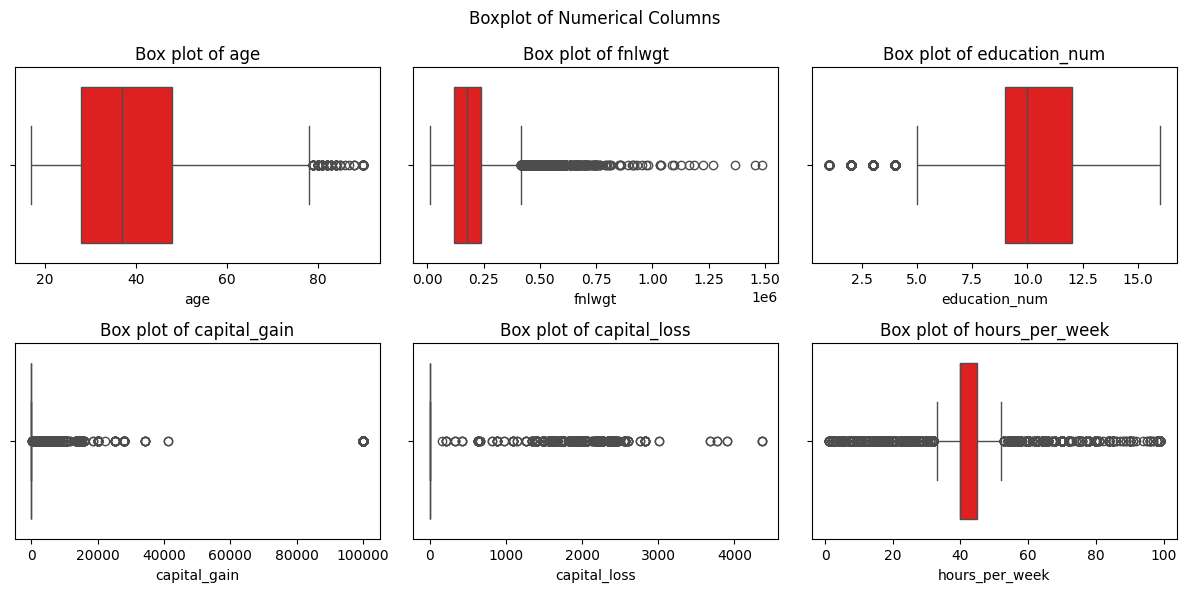

In [180]:
fig,ax = plt.subplots(2,3,figsize=(12,6))
for axis,col in zip(ax.flat,numerical_cols):
  sns.boxplot(data=df,x=col,ax=axis,color="red")
  axis.set_title(f"Box plot of {col}")
  axis.set_xlabel(col)

plt.suptitle("Boxplot of Numerical Columns")
plt.tight_layout()
plt.show()

**Observation :**
- **Age:** Most individuals are between 28–48 years, with a few higher-age outliers.
- **fnlwgt:** Highly right-skewed with several high-value outliers.
- **education_num:** Mostly concentrated between 9–12; lower values are valid education categories.
- **capital_gain & capital_loss:** Most values are zero, with a few extremely high values causing many outliers.
- **hours_per_week:** Most individuals work around 40–45 hours, with some extreme low and high values.

## HISTPLOT ANALYSIS

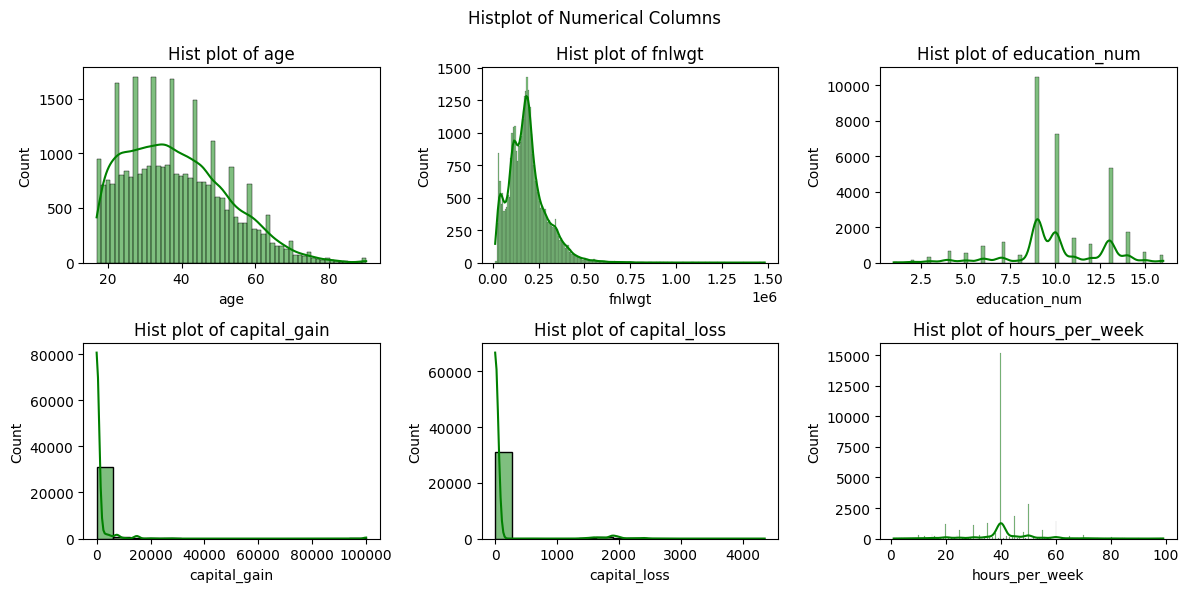

In [181]:
fig,ax = plt.subplots(2,3,figsize=(12,6))
for axis,col in zip(ax.flat,numerical_cols):
  sns.histplot(data=df,x=col,ax=axis,color="g",kde=True)
  axis.set_title(f"Hist plot of {col}")
  axis.set_xlabel(col)

plt.suptitle("Histplot of Numerical Columns")
plt.tight_layout()
plt.show()

**Observation :**
- **Age:** Slightly right-skewed, with most individuals between 20–50 years.
- **fnlwgt:** Positively skewed with a long right tail.
- **education_num:** Shows spikes because it contains discrete education levels.
- **capital_gain & capital_loss:** Extremely right-skewed and dominated by zero values.
- **hours_per_week:** Strong peak at 40 hours, making it the most common working schedule.

## COUNTPLOT ANALYSIS

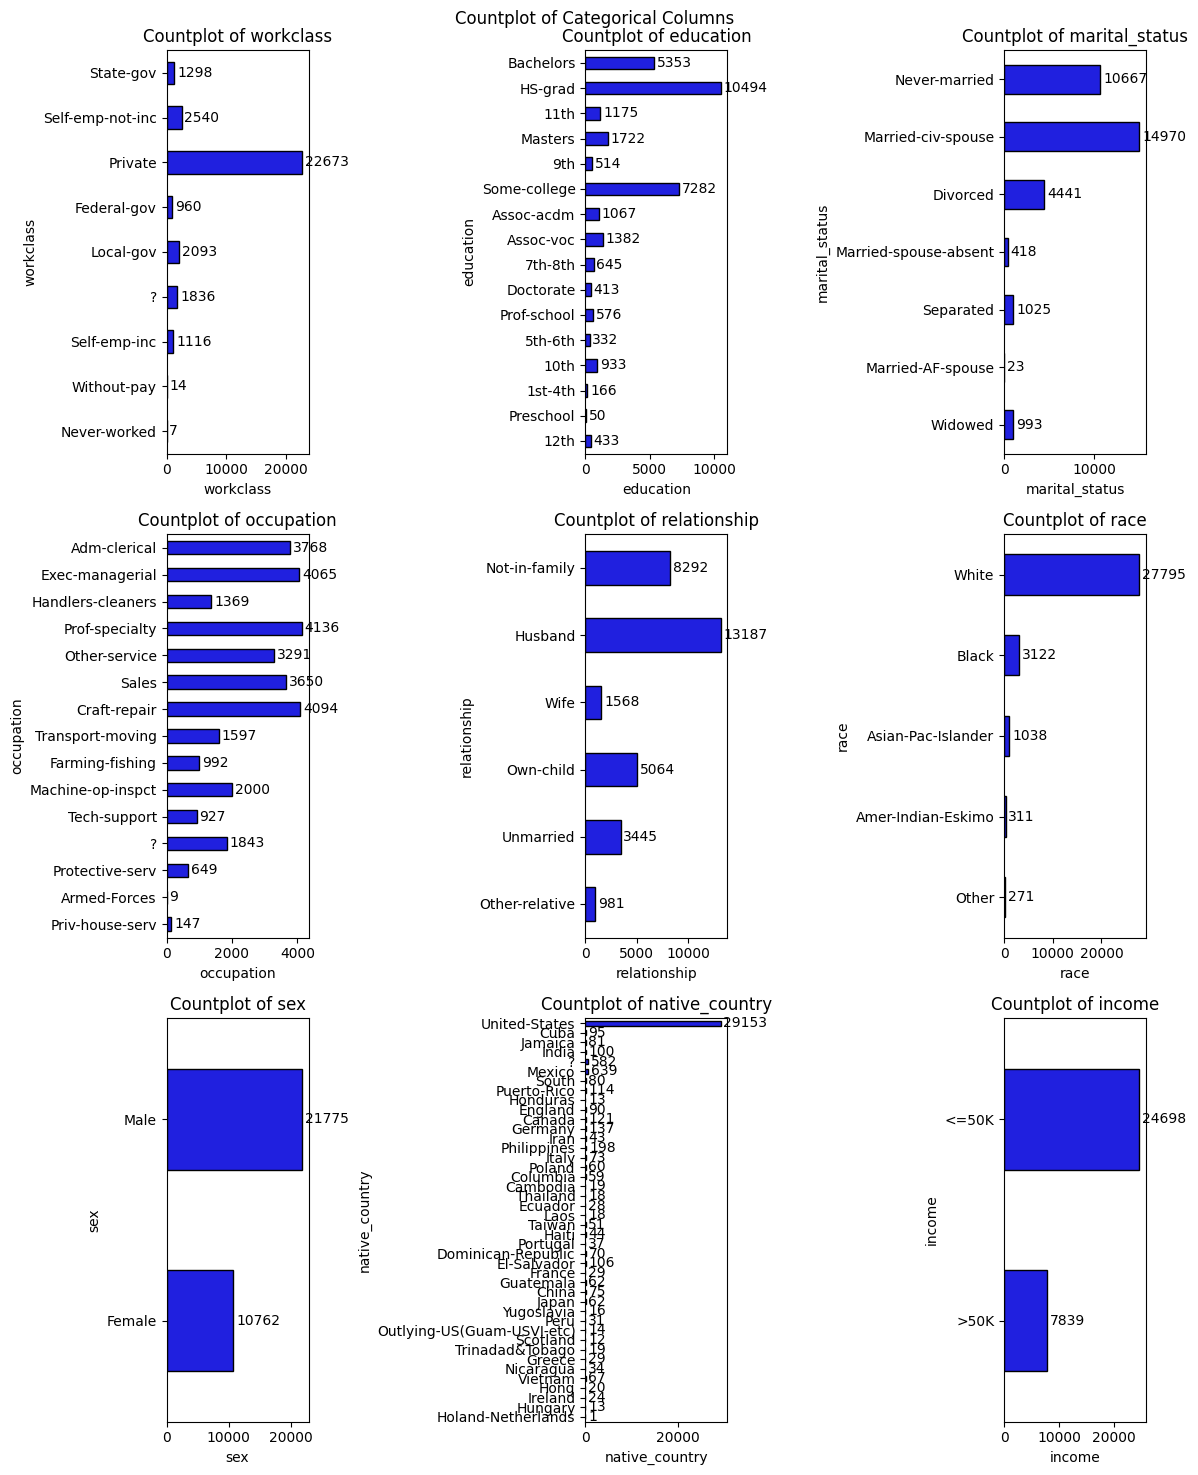

In [182]:
fig,ax = plt.subplots(3,3,figsize=(12,15))
for axis,col in zip(ax.flat,categorical_cols):
  sns.countplot(data=df,y=col,ax=axis,color="blue",edgecolor="black",width=0.5)
  axis.set_title(f"Countplot of {col}")
  axis.set_xlabel(col)

  for container in axis.containers:
    axis.bar_label(container,padding=2)

plt.suptitle("Countplot of Categorical Columns")
plt.tight_layout()
plt.show()

**Observation :**

- `Private sector` is dominating with 69% of records in workclass.
- The vast majority of education records (71%) consist of `high school graduates`, `college students`, and `bachelor's degree holders`.
- Morethan three quarters of all marital_status records are made up of `Never Married` and `Married-civ-spouse.`
- Occupation variable has very good distribution among its categories.
- Almost 66% of relationship records are made up of `Not-in-family` and `Husband` categories.
- The `White` people of `United States` make up of almost 78% of the datset.
- The `Males` are dominating `females` with 66% of records in sex.
- Almost Three Quarters of the records are made up of lessthan or equal to 50K income.

## CORRELATION MATRIX

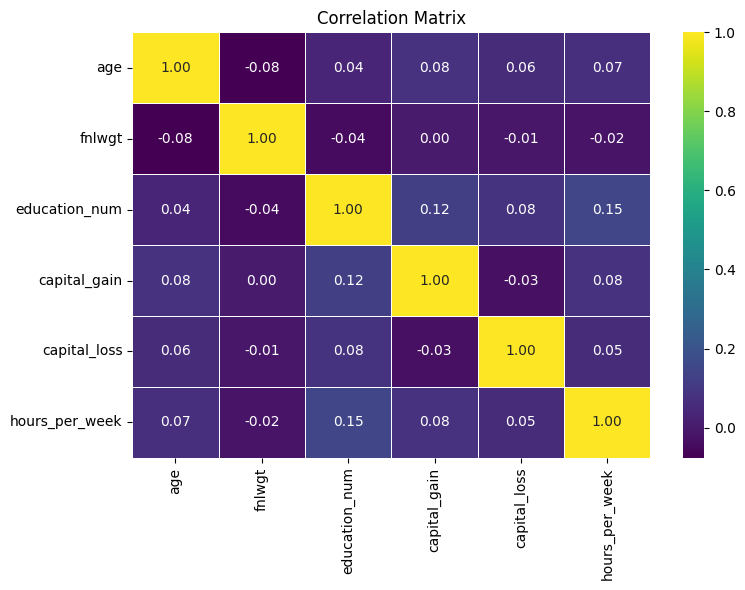

In [183]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",linewidths=0.5,cmap="viridis")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Observation :**

Surprisingly, none of the numerical variables show a strong correlation with each other. Most correlation values are close to zero, indicating weak or negligible linear relationships between the numerical features. The highest correlation is approximately 0.15 between education_num and hours_per_week, which is still considered weak

## CRAMER'S V ASSOCIATION MATRIX

In [184]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)

    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()

    phi2 = chi2 / n

    r, k = contingency_table.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))

In [185]:
categorical_cols = df.select_dtypes(include='object').columns

cramers_matrix = pd.DataFrame(
    index=categorical_cols,
    columns=categorical_cols
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(
            df[col1],
            df[col2]
        )

cramers_matrix = cramers_matrix.astype(float)

cramers_matrix

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
workclass,1.000000,0.099383,0.085001,0.400027,0.098685,0.056289,0.153680,0.045742,0.179187
education,0.099383,1.000000,0.091648,0.187070,0.122590,0.075001,0.095650,0.132042,0.368922
marital_status,0.085001,0.091648,1.000000,0.133181,0.487966,0.084217,0.461807,0.073098,0.447314
occupation,0.400027,0.187070,0.133181,1.000000,0.178618,0.080844,0.424177,0.071320,0.351945
relationship,0.098685,0.122590,0.487966,0.178618,1.000000,0.098132,0.649109,0.085501,0.453516
race,0.056289,0.075001,0.084217,0.080844,0.098132,1.000000,0.118379,0.409450,0.100853
sex,0.153680,0.095650,0.461807,0.424177,0.649109,0.118379,0.999931,0.067199,0.215893
native_country,0.045742,0.132042,0.073098,0.071320,0.085501,0.409450,0.067199,1.000000,0.098464
income,0.179187,0.368922,0.447314,0.351945,0.453516,0.100853,0.215893,0.098464,0.999916


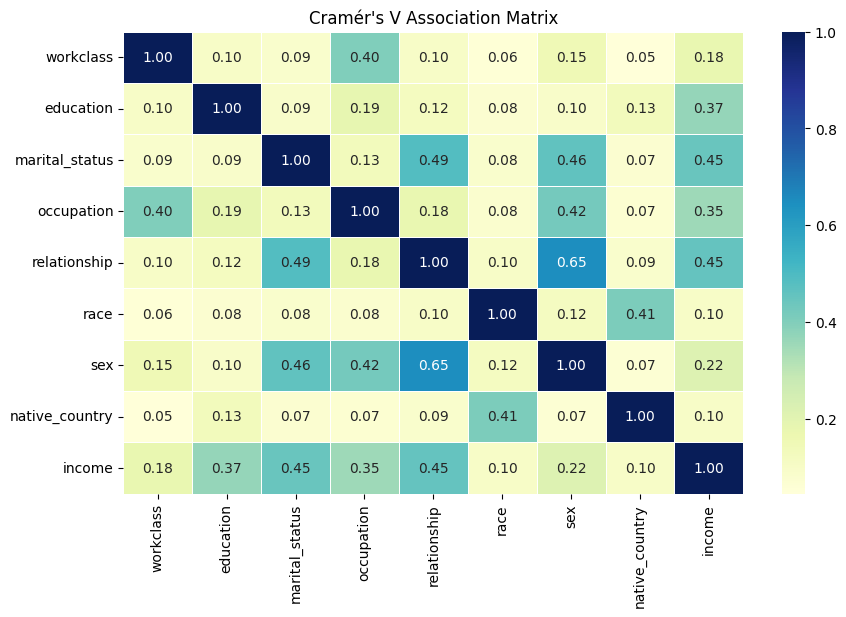

In [186]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f',linewidths = 0.5
)

plt.title("Cramér's V Association Matrix")
plt.show()

# Log Transformation

In [187]:
numerical_cols = df.select_dtypes(include = np.number).columns
df[numerical_cols].skew().sort_values(ascending=False)

,0
capital_gain,11.949403
capital_loss,4.592702
fnlwgt,1.447703
age,0.557663
hours_per_week,0.228759
education_num,-0.309500


In [188]:
df["capital_gain_log"] = np.log1p(df["capital_gain"])
df["capital_loss_log"] = np.log1p(df["capital_loss"])
print("Original Skewness of capital_gain : ",df["capital_gain"].skew())
print("Log Transformed capital gain Skewness : ",df["capital_gain_log"].skew())
print("="*60)
print("Original Skewness of capital_loss : ",df["capital_loss"].skew())
print("Log Transformed capital loss Skewness : ",df["capital_loss_log"].skew())

Original Skewness of capital_gain :  11.949402833551463
Log Transformed capital gain Skewness :  3.094666793136126
Original Skewness of capital_loss :  4.592702423271812
Log Transformed capital loss Skewness :  4.305700984352209


In [189]:
numerical_cols = df.select_dtypes(include = np.number).columns
df[numerical_cols].skew().sort_values(ascending=False)

,0
capital_gain,11.949403
capital_loss,4.592702
capital_loss_log,4.305701
capital_gain_log,3.094667
fnlwgt,1.447703
age,0.557663
hours_per_week,0.228759
education_num,-0.309500


In [190]:
skewness_comparison = pd.DataFrame({"Before Log Transformation":[df["capital_gain"].skew(),df["capital_loss"].skew()],
                         "After Log Transformation": [df["capital_gain_log"].skew(),df["capital_loss_log"].skew()] }
                          ,index=["capital_gain","capital_loss"])
skewness_comparison


,Before Log Transformation,After Log Transformation
capital_gain,11.949403,3.094667
capital_loss,4.592702,4.305701


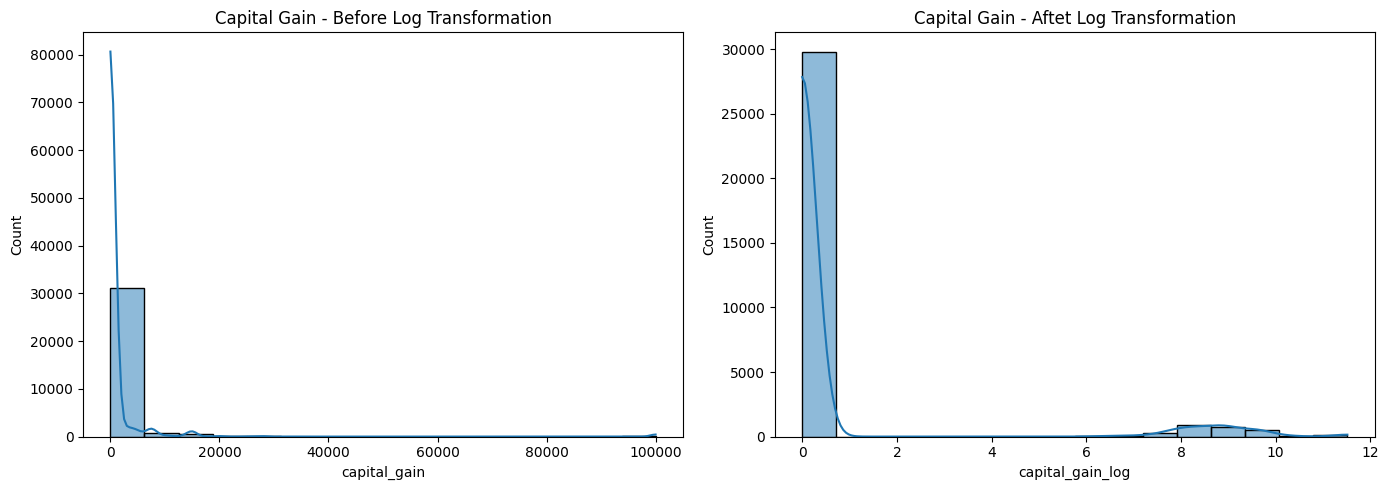

In [191]:
fig,ax = plt.subplots(1,2,figsize =(14,5))

sns.histplot(data =df["capital_gain"],kde=True,ax=ax[0])
ax[0].set_title("Capital Gain - Before Log Transformation")

sns.histplot(data = df["capital_gain_log"],kde=True,ax=ax[1])
ax[1].set_title("Capital Gain - Aftet Log Transformation")

plt.tight_layout()
plt.show()

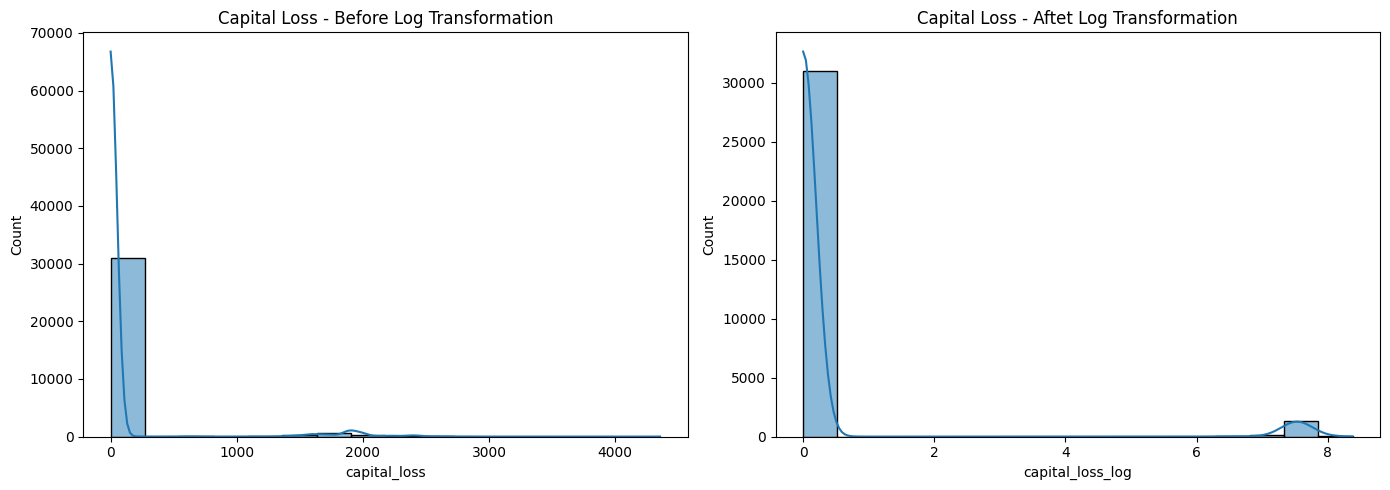

In [192]:
fig,ax = plt.subplots(1,2,figsize =(14,5))

sns.histplot(data =df["capital_loss"],kde=True,ax=ax[0])
ax[0].set_title("Capital Loss - Before Log Transformation")

sns.histplot(data = df["capital_loss_log"],kde=True,ax=ax[1])
ax[1].set_title("Capital Loss - Aftet Log Transformation")

plt.tight_layout()
plt.show()

**Observation :**

The log transformation significantly reduced the skewness of `capital_gain` from 11.95 to 3.09, indicating that the transformation effectively reduced the influence of extreme values. However, `capital_loss` showed only a slight reduction in skewness from 4.59 to 4.31, mainly due to the large concentration of zero values. Therefore, the log transformation was more effective for `capital_gain` than for `capital_loss`.

# Feature Engineering

## Feature 1 : Net Capital

In [193]:
df["net_capital"] = df["capital_gain"] - df["capital_loss"]

df[["capital_gain","capital_loss","net_capital"]].head()

,capital_gain,capital_loss,net_capital
0,2174,0,2174
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


## Feature 2 : Age Groups

In [194]:
df["age_group"] = pd.cut(df["age"],bins=[0,21,30,50,70,100],labels=["Young","Young_Adult","Mid_Career","Senior","Retired"])
df["age_group"].value_counts()


,count
age_group,
Mid_Career,15520
Young_Adult,7435
Senior,5920
Young,3123
Retired,539


In [195]:
print("Dataset Shape:", df.shape)

print("\nNew Features Added:")
print(["net_capital", "age_group"])

df.head()

Dataset Shape: (32537, 19)

New Features Added:
['net_capital', 'age_group']


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_gain_log,capital_loss_log,net_capital,age_group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,7.684784,0.0,2174,Mid_Career
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0.000000,0.0,0,Mid_Career
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0.000000,0.0,0,Mid_Career
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0.000000,0.0,0,Senior
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0.000000,0.0,0,Young_Adult


# Scaling

In [196]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_cols.tolist())

Numerical Columns:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'capital_gain_log', 'capital_loss_log', 'net_capital']


## StandardScaler

In [197]:
df_standard_scaled = df.copy()
scaler = StandardScaler()
df_standard_scaled[numerical_cols] = scaler.fit_transform(df_standard_scaled[numerical_cols])
df_standard_scaled.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_gain_log,capital_loss_log,net_capital,age_group
0,0.030390,State-gov,-1.063569,Bachelors,1.134777,Never-married,Adm-clerical,Not-in-family,White,Male,0.148292,-0.216743,-0.035664,United-States,<=50K,2.830199,-0.22116,0.159605,Mid_Career
1,0.836973,Self-emp-not-inc,-1.008668,Bachelors,1.134777,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145975,-0.216743,-2.222483,United-States,<=50K,-0.299391,-0.22116,-0.133720,Mid_Career
2,-0.042936,Private,0.245040,HS-grad,-0.420679,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K,-0.299391,-0.22116,-0.133720,Mid_Career
3,1.056950,Private,0.425752,11th,-1.198407,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K,-0.299391,-0.22116,-0.133720,Senior
4,-0.776193,Private,1.408066,Bachelors,1.134777,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145975,-0.216743,-0.035664,Cuba,<=50K,-0.299391,-0.22116,-0.133720,Young_Adult


**Observation :**

Standard Scaling was applied to the numerical features. This transformation standardizes each feature to have a mean of approximately 0 and a standard deviation of approximately 1. It is particularly useful for machine learning algorithms that are sensitive to the scale of input features, such as KNN, SVM, and Logistic Regression.

## Min-Max Scaler

In [198]:
df_minmax_scaled = df.copy()
scaler = MinMaxScaler()
df_minmax_scaled[numerical_cols] = scaler.fit_transform(df_minmax_scaled[numerical_cols])
df_minmax_scaled.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_gain_log,capital_loss_log,net_capital,age_group
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K,0.667492,0.0,0.062575,Mid_Career
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K,0.000000,0.0,0.041742,Mid_Career
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K,0.000000,0.0,0.041742,Mid_Career
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K,0.000000,0.0,0.041742,Senior
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K,0.000000,0.0,0.041742,Young_Adult


**Observation:**

Min-Max Scaling was applied to normalize numerical features into the range of 0 to 1. This technique is useful when features have different ranges and when a fixed range is preferred, particularly for distance-based algorithms and certain neural network models.

## Standard Scaling vs Min-Max Scaling

### Standard Scaling

- Converts features to have a mean of approximately 0 and a standard deviation of approximately 1.
- Preferred for algorithms sensitive to feature magnitude and distance, such as Logistic Regression, SVM, and KNN.
- More suitable when the data is approximately normally distributed.

### Min-Max Scaling

- Rescales values to a fixed range, typically 0 to 1.
- Useful when a bounded range is required, such as in Neural Networks.
- Preserves the relative relationships between values but can be sensitive to extreme outliers.

# Encoding

In [199]:
categorical_cols = df.select_dtypes(include=["object","category"]).columns

category_counts = pd.DataFrame({"Column": categorical_cols,"Unique Categories":[df[col].nunique() for col in categorical_cols]})

category_counts

,Column,Unique Categories
0,workclass,9
1,education,16
2,marital_status,7
3,occupation,15
4,relationship,6
5,race,5
6,sex,2
7,native_country,42
8,income,2
9,age_group,5


## One-Hot Encoding

In [200]:
one_hot_cols = ["sex","income"]

In [201]:
df_encoded = df.copy()
df_encoded = pd.get_dummies(df,columns=one_hot_cols,drop_first=True)
df_encoded.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,capital_gain_log,capital_loss_log,net_capital,age_group,sex_Male,income_>50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,7.684784,0.0,2174,Mid_Career,True,False
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,0.000000,0.0,0,Mid_Career,True,False
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,0.000000,0.0,0,Mid_Career,True,False
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,0.000000,0.0,0,Senior,True,False
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,0.000000,0.0,0,Young_Adult,False,False


**Observation :**

One-Hot Encoding was applied to sex and income, as these variables contain fewer than 5 categories. The categorical values were converted into binary numerical features suitable for machine learning algorithms.

## Label Encoding

In [202]:
label_encode_cols = ["race","age_group","workclass","education","marital_status","occupation","relationship","native_country"]

In [203]:
encoder = LabelEncoder()

for col in label_encode_cols:
  df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,capital_gain_log,capital_loss_log,net_capital,age_group,sex_Male,income_>50K
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,7.684784,0.0,2174,0,True,False
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,0.000000,0.0,0,0,True,False
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,0.000000,0.0,0,0,True,False
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,0.000000,0.0,0,2,True,False
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,0.000000,0.0,0,4,False,False


**Observation :**

Label Encoding was applied to the selected categorical variables to convert them into numerical representations. While Label Encoding is memory-efficient and particularly suitable for ordinal features and tree-based models, it may introduce artificial ordering for purely nominal categories.

In [204]:
df_encoded.dtypes

,0
age,int64
workclass,int64
fnlwgt,int64
education,int64
education_num,int64
marital_status,int64
occupation,int64
relationship,int64
race,int64
capital_gain,int64


**Final Encoding Observation :**

After applying One-Hot Encoding and Label Encoding, all categorical features were successfully converted into numerical representations. The final dataset contains only numerical data types, making it suitable for machine learning algorithms.

## Encoding Techniques - Pros and Cons



### One-Hot Encoding
**Advantages :**

- Does not introduce an artificial order between categories.
- Suitable for nominal categorical variables.
- Easy for machine learning algorithms to interpret.

**Disadvantages :**

- Can significantly increase the number of features when a variable has many categories.
- Can increase memory usage and computational complexity.

### Label Encoding

**Advantages :**

- Converts categories into numerical values without increasing the number of features.
- Memory efficient.
- Works particularly well with tree-based algorithms.

**Disadvantages :**

- May introduce an artificial ordinal relationship between categories.
- May negatively affect distance-based algorithms when categories are purely nominal.

# Conclusion

In this assignment, the Adult Income dataset was successfully preprocessed and transformed to make it suitable for machine learning. The dataset was examined for missing values, duplicates, data types, and feature distributions. Highly skewed features were identified, and log transformation was applied to `capital_gain` and `capital_loss` to reduce the influence of extreme values.

Feature engineering was performed by creating `net_capital` and `age_group` to provide additional meaningful information. Numerical features were transformed using both Standard Scaling and Min-Max Scaling to demonstrate different scaling techniques. Categorical variables were converted into numerical form using One-Hot Encoding and Label Encoding based on their cardinality.

Overall, these preprocessing and feature engineering steps improved the structure and usability of the dataset. The final dataset contains machine-learning-compatible numerical features and is ready for further feature selection and model development.